# EduInsight — Notebook 1: Data Understanding

## Objective

Inspect the structure and quality of the Open University Learning Analytics
Dataset before any cleaning, feature engineering, or modelling.

## Main question

How can activity available during the first 30 days help identify student
profiles that may benefit from additional academic support?

## 1. Reproducible project configuration

This notebook defines every path and configuration value it uses. It does
not depend on variables created in another notebook.

In [1]:
from pathlib import Path
import sys


def locate_project_root(
    start: Path | None = None,
) -> Path:
    current = (start or Path.cwd()).resolve()

    for candidate in (current, *current.parents):
        if (
            (candidate / "src").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Open VS Code from the repository "
        "folder and run the notebook again."
    )


PROJECT_ROOT = locate_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"


SELECTED_MODULE = "BBB"
SELECTED_PRESENTATION = "2013J"
CUTOFF_DAY = 30


print(f"Project root: {PROJECT_ROOT}")

Project root: D:\Work\GIT\eduinsight-student-success


## 2. Imports and raw-file validation

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.data_preparation import (
    load_csv,
    summarize_missing_values,
    validate_raw_data_files,
    validate_unique_key,
)


pd.set_option("display.max_columns", None)

validate_raw_data_files(RAW_DATA_DIR)

## 3. Load the student information table

In [3]:
student_info = load_csv(
    RAW_DATA_DIR,
    "studentInfo.csv",
)

print(f"Rows: {student_info.shape[0]:,}")
print(f"Columns: {student_info.shape[1]}")

student_info.head()

Rows: 32,593
Columns: 12


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


## 4. Inspect schema and data types

In [4]:
student_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 4.8 MB


In [5]:
column_summary = pd.DataFrame(
    {
        "dtype": student_info.dtypes.astype(str),
        "unique_values": student_info.nunique(
            dropna=True
        ),
    }
)

column_summary

,dtype,unique_values
code_module,str,7
code_presentation,str,4
id_student,int64,28785
gender,str,2
region,str,13
highest_education,str,5
imd_band,str,10
age_band,str,3
num_of_prev_attempts,int64,7
studied_credits,int64,61


## 5. Missing values

In [6]:
missing_summary = summarize_missing_values(
    student_info
)

missing_summary

,missing_values,missing_percentage
imd_band,1111,3.41
code_module,0,0.00
code_presentation,0,0.00
id_student,0,0.00
gender,0,0.00
region,0,0.00
highest_education,0,0.00
age_band,0,0.00
num_of_prev_attempts,0,0.00
studied_credits,0,0.00


Missing values are investigated before any deletion or imputation. A blank
value may have a domain meaning, so removing rows without examination would
be unsafe.

In [7]:
student_info.dropna()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn


## 6. Duplicate and logical-key checks

In [8]:
exact_duplicate_count = int(
    student_info.duplicated().sum()
)

print(
    f"Exact duplicate rows: "
    f"{exact_duplicate_count}"
)

validate_unique_key(
    student_info,
    (
        "code_module",
        "code_presentation",
        "id_student"
    ),
    dataframe_name="student_info"
)

print("Composite student key is unique.")

Exact duplicate rows: 0
Composite student key is unique.


## 7. Final-result distribution

In [9]:
result_summary = (
    student_info["final_result"]
    .value_counts(dropna=False)
    .rename_axis("final_result")
    .to_frame("count")
)


result_summary["percentage"] = (
    result_summary["count"]
    / len(student_info)
    * 100
).round(2)


result_summary

,count,percentage
final_result,,
Pass,12361,37.93
Withdrawn,10156,31.16
Fail,7052,21.64
Distinction,3024,9.28


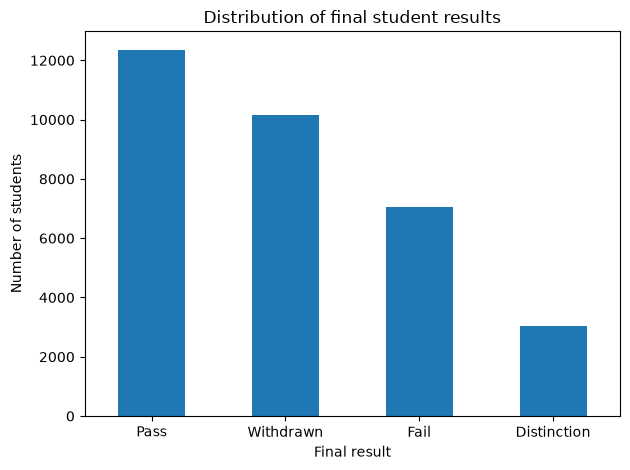

In [10]:
result_summary["count"].plot(
    kind="bar"
)

plt.title(
    "Distribution of final student results"
)
plt.xlabel("Final result")
plt.ylabel("Number of students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** the target classes are not equally represented.
Therefore, later model evaluation will include precision, recall, F1-score,
balanced accuracy, ROC-AUC, and average precision—not accuracy alone.

## 8. Compare module presentations

In [11]:
presentation_summary = (
    student_info
    .groupby(
        [
            "code_module",
            "code_presentation",
        ]
    )
    .agg(
        student_count=(
            "id_student",
            "size",
        ),
        support_category_count=(
            "final_result",
            lambda values: values.isin(
                ["Fail", "Withdrawn"]
            ).sum(),
        ),
    )
    .reset_index()
)


presentation_summary[
    "support_category_percentage"
] = (
    presentation_summary[
        "support_category_count"
    ]
    / presentation_summary["student_count"]
    * 100
).round(2)


presentation_summary.sort_values(
    "student_count",
    ascending=False,
)

,code_module,code_presentation,student_count,support_category_count,support_category_percentage
7,CCC,2014J,2498,1483,59.37
18,FFF,2014J,2365,1248,52.77
5,BBB,2014J,2292,1140,49.74
16,FFF,2013J,2283,1188,52.04
3,BBB,2013J,2237,1165,52.08
9,DDD,2013J,1938,1109,57.22
6,CCC,2014B,1936,1273,65.75
11,DDD,2014J,1803,1011,56.07
2,BBB,2013B,1767,964,54.56
15,FFF,2013B,1614,832,51.55


## 9. Confirm the selected presentation

In [12]:
selected_students = student_info.loc[
    student_info["code_module"].eq(
        SELECTED_MODULE
    )
    & student_info[
        "code_presentation"
    ].eq(
        SELECTED_PRESENTATION
    )
].copy()


if selected_students.empty:
    raise ValueError(
        f"The selected presentation "
        f"{SELECTED_MODULE} "
        f"{SELECTED_PRESENTATION} "
        "does not exist in studentInfo.csv."
    )


print(
    f"Selected "
    f"{SELECTED_MODULE} "
    f"{SELECTED_PRESENTATION}: "
    f"{len(selected_students):,} "
    "student records"
)


selected_students[
    "final_result"
].value_counts().to_frame(
    "students"
)

Selected BBB 2013J: 2,237 student records


,students
final_result,
Pass,896
Withdrawn,644
Fail,521
Distinction,176


## 10. Initial observations

1. The dataset contains four outcome categories, and the class sizes differ.
2. The composite key is the module, presentation, and student identifier—not
   the student identifier alone.
3. Missing values must be treated according to their column meaning rather
   than removed automatically.
4. Pass is the most common result in the selected presentation.
5. The withdrawal category represents approximately X% of the records.

## Completion check

Notebook 1 is complete when every cell runs from top to bottom without an
error and the written observations match the displayed results.